<a href="https://colab.research.google.com/github/muhnatha/binary-machine-generated-code-detection/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hugging Face Token API Setup

In [1]:
# Check Token
from google.colab import userdata
from huggingface_hub import HfApi

api = HfApi()
HF_TOKEN = userdata.get('HF_TOKEN')

user = api.whoami(HF_TOKEN)
print("Logged in as:", user["name"])

Logged in as: lituldust


# Import Library

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


# Import Dataset

In [3]:
from google.colab import files

files = files.upload().values()

Saving test_features.csv to test_features.csv
Saving train_features.csv to train_features.csv
Saving validation_features.csv to validation_features.csv


In [4]:
train_df = pd.read_csv("/content/train_features.csv")
val_df = pd.read_csv("/content/validation_features.csv")
test_df = pd.read_csv("/content/test_features.csv")

In [5]:
print("--SUMMARY--\n")
print(f"Number of train samples: {len(train_df)}")
print(f"Number of validation samples: {len(val_df)}")
print(f"Number of test samples: {len(test_df)}")


--SUMMARY--

Number of train samples: 5000
Number of validation samples: 2000
Number of test samples: 1000


In [6]:
train_df.head()

,label,avg_loss,std_loss,burstiness,code
0,0,3.355464,1.671374,2.026438,"N = int(input())\r\nfor m in range(1, 10 ** 9):\r\n\tif m * (m + 1) // 2 >= N:\r\n\t\tbreak\r\nf..."
1,0,2.893400,0.814801,1.488926,"total_number = int(input())\r\nmy_list = input()\r\nuser_list = my_list.split()\r\n(a, b, c) = (..."
2,0,3.082699,1.140045,1.841777,n = int(input())\r\nl = []\r\nfor i in range(n):\r\n\ts = input()\r\n\ta = s.split()[0]\r\n\tb =...
3,0,3.377587,0.788948,1.378054,n = int(input())\r\nsubstrs = input().split()\r\narray = [int(x) for x in substrs]\r\ndays = 0\r...
4,1,2.469890,0.601108,1.451823,java\r\nimport java.io.*;\r\nimport java.util.*;\r\n\r\npublic class Main {\r\n public static...


# Exploratory Data Analysis

In [7]:
print("=" * 50)
print("TRAINING DATASET INFO")
print("=" * 50)
train_df.info()

TRAINING DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   label       5000 non-null   int64  
 1   avg_loss    5000 non-null   float64
 2   std_loss    5000 non-null   float64
 3   burstiness  5000 non-null   float64
 4   code        5000 non-null   object 
dtypes: float64(3), int64(1), object(1)
memory usage: 195.4+ KB


## Label Distribution

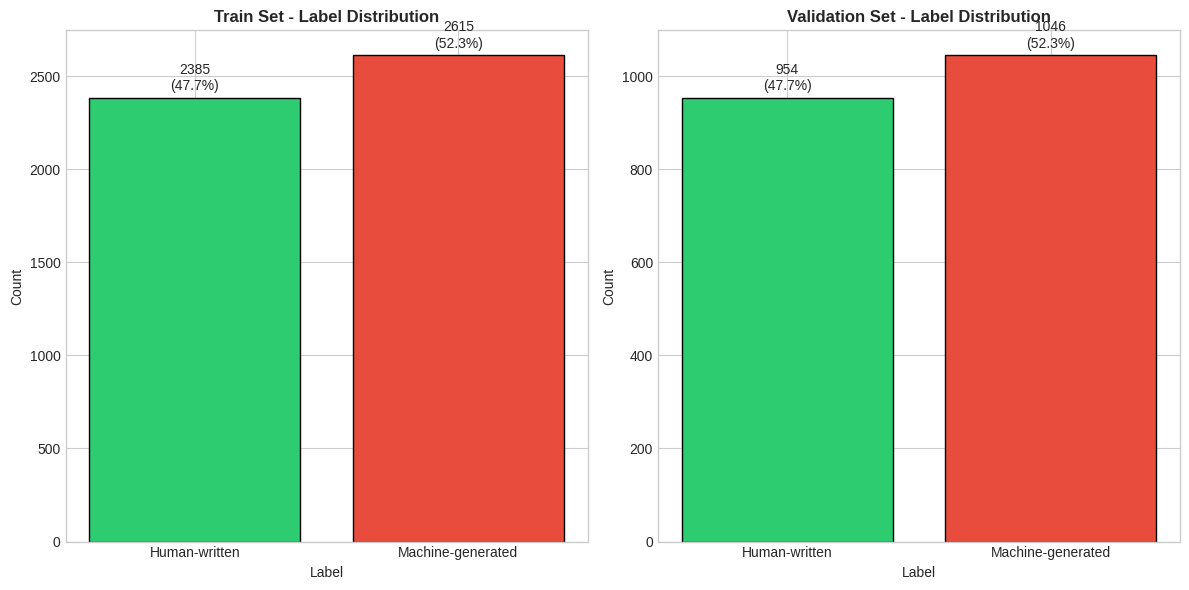


Label Distribution Summary:

Train: {'Human-written': 2385, 'Machine-generated': 2615}

Validation: {'Human-written': 954, 'Machine-generated': 1046}


In [8]:
# Label distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

datasets = [('Train', train_df), ('Validation', val_df)]
label_map = {0: 'Human-written', 1: 'Machine-generated'}

for idx, (name, df) in enumerate(datasets):
    ax = axes[idx]

    if 'label' in df.columns:
        counts = df['label'].value_counts().sort_index()

        x_tick_labels = [label_map.get(i, i) for i in counts.index]

        bars = ax.bar(x_tick_labels, counts.values,
                      color=['#2ecc71', '#e74c3c'], edgecolor='black')

        ax.set_title(f'{name} Set - Label Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('Label')
        ax.set_ylabel('Count')

        total = len(df)
        for container in ax.containers:
            labels = [f'{v:.0f}\n({v/total*100:.1f}%)' for v in container.datavalues]

            ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=10)

    else:
        ax.text(0.5, 0.5, 'No label column', ha='center', va='center')
        ax.set_title(f'{name} Set')

plt.tight_layout()
plt.show()

print("\nLabel Distribution Summary:")
for name, df in datasets:
    if 'label' in df.columns:
        counts = df['label'].value_counts().sort_index()
        mapped_counts = {label_map.get(k, k): v for k, v in counts.items()}
        print(f"\n{name}: {mapped_counts}")

## Feature Distribution

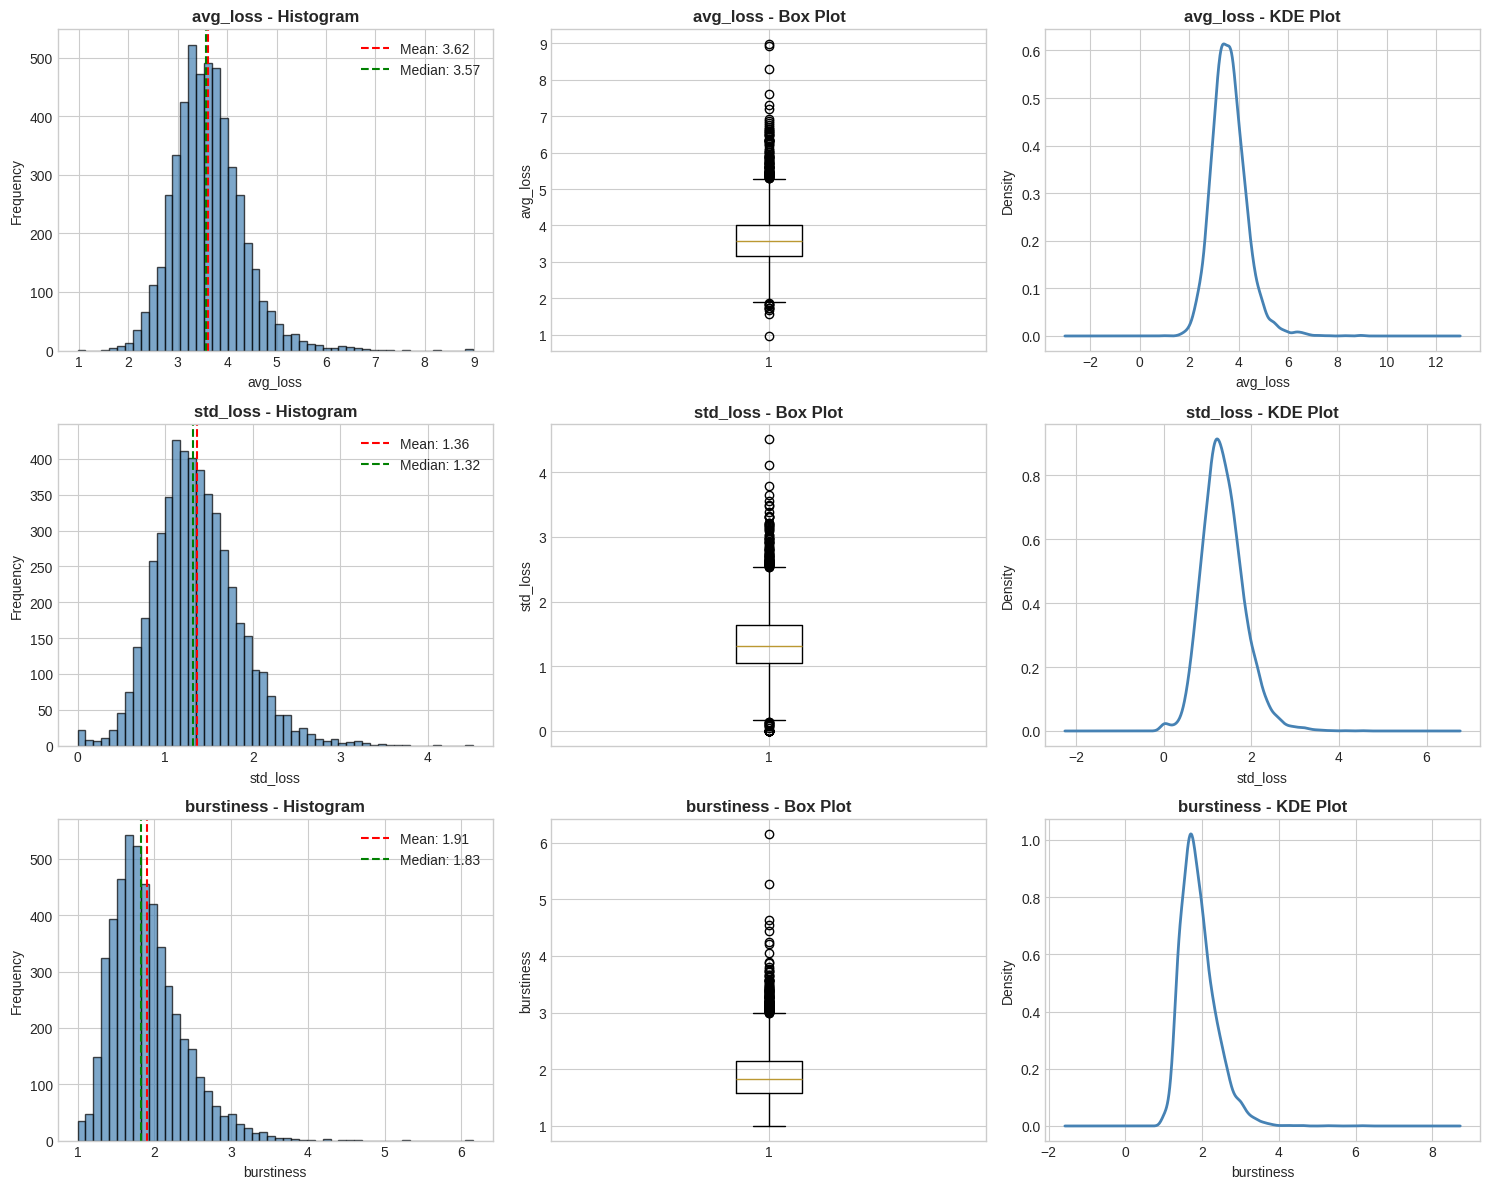

In [9]:
# Distribution of numerical features
numerical_cols = ['avg_loss', 'std_loss', 'burstiness']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[i, 0].hist(train_df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i, 0]. set_title(f'{col} - Histogram', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].axvline(train_df[col].mean(), color='red', linestyle='--', label=f'Mean: {train_df[col].mean():.2f}')
    axes[i, 0].axvline(train_df[col].median(), color='green', linestyle='--', label=f'Median: {train_df[col].median():.2f}')
    axes[i, 0]. legend()

    # Box plot
    axes[i, 1]. boxplot(train_df[col], vert=True)
    axes[i, 1].set_title(f'{col} - Box Plot', fontweight='bold')
    axes[i, 1]. set_ylabel(col)

    # KDE plot
    train_df[col]. plot(kind='kde', ax=axes[i, 2], color='steelblue', linewidth=2)
    axes[i, 2].set_title(f'{col} - KDE Plot', fontweight='bold')
    axes[i, 2]. set_xlabel(col)

plt.tight_layout()
plt.show()

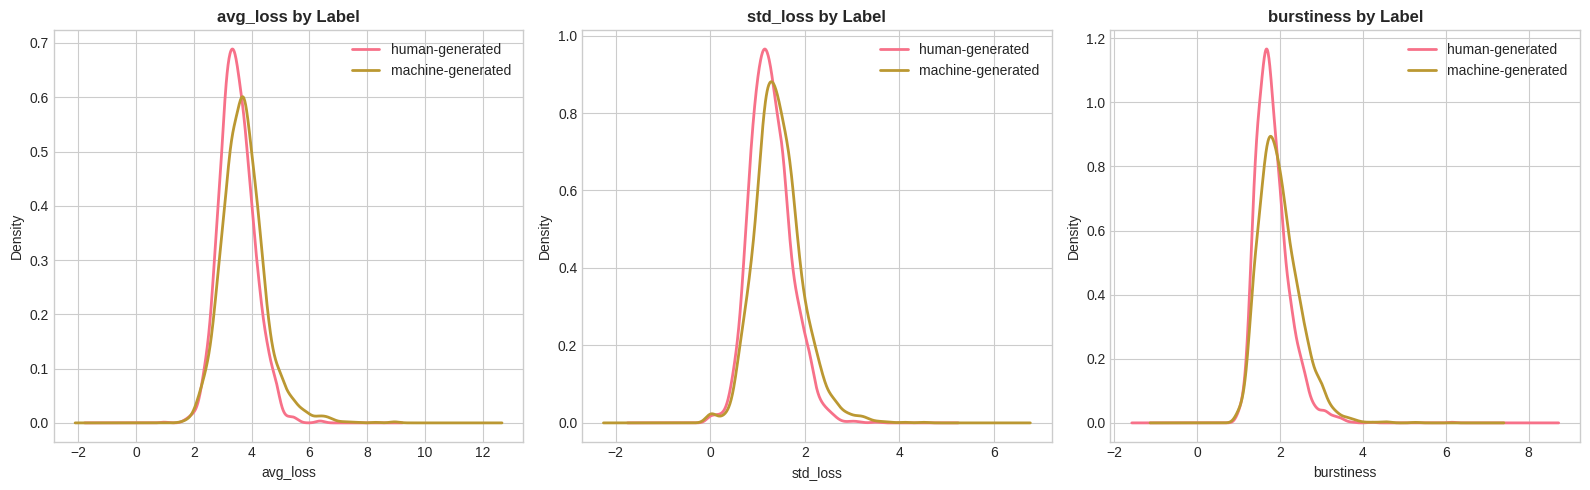


Statistical Comparison by Label:
                   avg_loss                      std_loss                      \
                       mean       std    median      mean       std    median   
label                                                                           
human-generated    3.494452  0.601980  3.450440  1.274475  0.430321  1.235175   
machine-generated  3.732800  0.769342  3.676464  1.443817  0.505187  1.400248   

                  burstiness                      
                        mean       std    median  
label                                             
human-generated     1.820325  0.410566  1.750257  
machine-generated   1.991413  0.494231  1.919134  


In [10]:
# Distribution of features by label
numerical_cols = ['avg_loss', 'std_loss', 'burstiness']
label_map = {0: 'human-generated', 1: 'machine-generated'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    for label in [0, 1]:
        subset = train_df[train_df['label'] == label][col]
        # Use label_map to get the string representation
        subset.plot(kind='kde', ax=axes[i], label=label_map[label], linewidth=2)

    axes[i].set_title(f'{col} by Label', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nStatistical Comparison by Label:")
print("=" * 60)
# We can also map the index here for the print output if you like
stats_df = train_df.groupby('label')[numerical_cols].agg(['mean', 'std', 'median'])
stats_df.index = stats_df.index.map(label_map)
print(stats_df)

# Programming Language Distribution

In [7]:
from google.colab import files

# Upload dataset.py
files = files.upload().values()

Saving dataset.py to dataset.py


In [11]:
train_df.head()

,label,avg_loss,std_loss,burstiness,code
0,0,3.355464,1.671374,2.026438,"N = int(input())\r\nfor m in range(1, 10 ** 9):\r\n\tif m * (m + 1) // 2 >= N:\r\n\t\tbreak\r\nf..."
1,0,2.893400,0.814801,1.488926,"total_number = int(input())\r\nmy_list = input()\r\nuser_list = my_list.split()\r\n(a, b, c) = (..."
2,0,3.082699,1.140045,1.841777,n = int(input())\r\nl = []\r\nfor i in range(n):\r\n\ts = input()\r\n\ta = s.split()[0]\r\n\tb =...
3,0,3.377587,0.788948,1.378054,n = int(input())\r\nsubstrs = input().split()\r\narray = [int(x) for x in substrs]\r\ndays = 0\r...
4,1,2.469890,0.601108,1.451823,java\r\nimport java.io.*;\r\nimport java.util.*;\r\n\r\npublic class Main {\r\n public static...


In [8]:
from dataset import RawCodeDataset

# Training Set (Subsampled & Stratified)
print("\n1. Loading Training Set...")
train_original = RawCodeDataset(split='train', subsample=True, sample_size=5000)

# Validation Set (Subsampled & Stratified)
print("\n2. Loading Validation Set...")
val_original = RawCodeDataset(split='validation', subsample=True, sample_size=2000)

# Test Set (Full - No Subsampling)
print("\n3. Loading Test Set...")
test_original = RawCodeDataset(split='test', subsample=False)


1. Loading Training Set...


README.md:   0%|          | 0.00/801 [00:00<?, ?B/s]

task_a/task_a_training_set_1.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

task_a/task_a_validation_set.parquet:   0%|          | 0.00/40.5M [00:00<?, ?B/s]

task_a/task_a_test_set_sample.parquet:   0%|          | 0.00/593k [00:00<?, ?B/s]

...

Casting to class labels:   0%|          | 0/500000 [00:00<?, ? examples/s]


2. Loading Validation Set...


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/100000 [00:00<?, ? examples/s]


3. Loading Test Set...


In [9]:
train_original = pd.DataFrame(list(train_original))
val_original = pd.DataFrame(list(val_original))
test_original = pd.DataFrame(list(test_original))

In [10]:
train_original.head()

,code,label,language
0,"N = int(input())\nfor m in range(1, 10 ** 9):\n\tif m * (m + 1) // 2 >= N:\n\t\tbreak\nfor i in ...",0,Python
1,"total_number = int(input())\nmy_list = input()\nuser_list = my_list.split()\n(a, b, c) = (0, 0, ...",0,Python
2,n = int(input())\nl = []\nfor i in range(n):\n\ts = input()\n\ta = s.split()[0]\n\tb = s.split()...,0,Python
3,n = int(input())\nsubstrs = input().split()\narray = [int(x) for x in substrs]\ndays = 0\nmax_pa...,0,Python
4,java\nimport java.io.*;\nimport java.util.*;\n\npublic class Main {\n public static void main...,1,Java


In [20]:
train_df['language'] = train_original['language']
val_df['language'] = val_original['language']

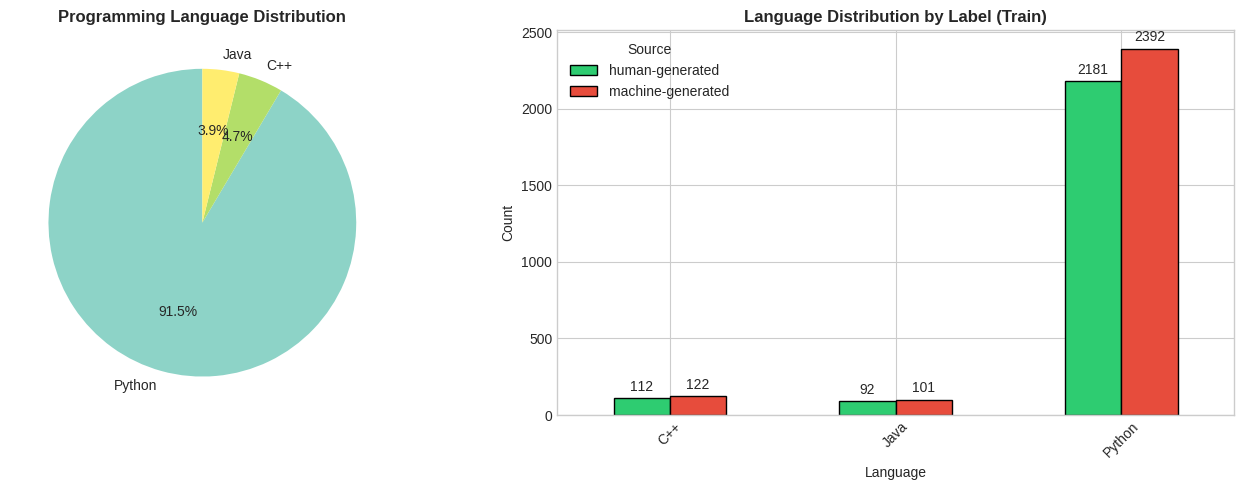


Language Distribution:
language
Python    4573
C++        234
Java       193
Name: count, dtype: int64


In [19]:
# Language distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Overall language distribution (Pie Chart)
lang_counts = train_df['language'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(lang_counts)))
axes[0].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Programming Language Distribution', fontweight='bold')

# 2. Language by label (Bar Chart)
lang_label = train_df.groupby(['language', 'label']).size().unstack(fill_value=0)

lang_label = lang_label.rename(columns={0: 'human-generated', 1: 'machine-generated'})

# Plotting
lang_label.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')

axes[1].set_title('Language Distribution by Label (Train)', fontweight='bold')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
axes[1].legend(title='Source')
axes[1].tick_params(axis='x', rotation=45)

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

print("\nLanguage Distribution:")
print(train_df['language'].value_counts())

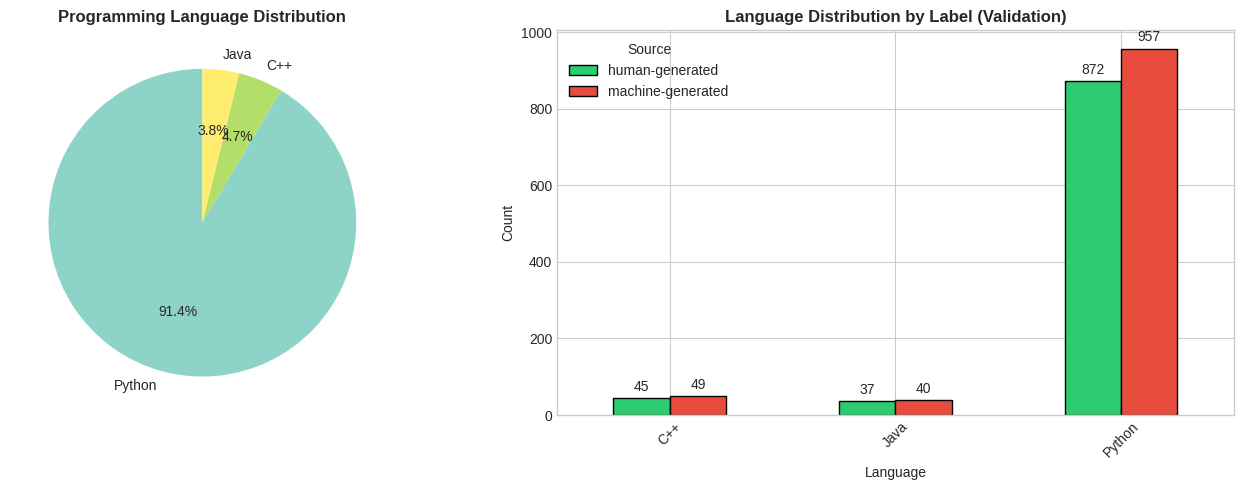


Language Distribution:
language
Python    4573
C++        234
Java       193
Name: count, dtype: int64


In [22]:
# Language distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Overall language distribution (Pie Chart)
lang_counts = val_df['language'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(lang_counts)))
axes[0].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Programming Language Distribution', fontweight='bold')

# 2. Language by label (Bar Chart)
lang_label = val_df.groupby(['language', 'label']).size().unstack(fill_value=0)

lang_label = lang_label.rename(columns={0: 'human-generated', 1: 'machine-generated'})

# Plotting
lang_label.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')

axes[1].set_title('Language Distribution by Label (Validation)', fontweight='bold')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')
axes[1].legend(title='Source')
axes[1].tick_params(axis='x', rotation=45)

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

print("\nLanguage Distribution:")
print(train_df['language'].value_counts())

# Before After Preprocessing

In [24]:
def clean_code(code):
    if pd.isna(code) or code == '':
        return ''

    # Convert to string
    code = str(code)

    # Normalize line endings
    code = code.replace('\r\n', '\n'). replace('\r', '\n')

    # Remove excessive whitespace while preserving structure
    lines = code.split('\n')
    cleaned_lines = []
    for line in lines:
        # Remove trailing whitespace
        cleaned_line = line. rstrip()
        cleaned_lines.append(cleaned_line)

    code = '\n'.join(cleaned_lines)

    # Remove multiple consecutive blank lines
    while '\n\n\n' in code:
        code = code.replace('\n\n\n', '\n\n')

    return code. strip()

def remove_comments(code):
    """Remove comments from code."""
    if pd.isna(code) or code == '':
        return ''

    code = str(code)

    # Remove single-line comments (// and #)
    code = re.sub(r'//.*', '', code)
    code = re.sub(r'#.*', '', code)

    # Remove multi-line comments (/* */ and ''' ''')
    code = re.sub(r'/\[\s\S]?\*/', '', code)
    code = re.sub(r"'''[\s\S]*?'''", '', code)
    code = re.sub(r'"""[\s\S]*?"""', '', code)

    return code.strip()

In [26]:
# Test the functions
sample_code = train_df['code']. iloc[3]
print("Original code (first 200 chars):")
print(sample_code[:200])
print("\nCleaned code (first 200 chars):")
print(clean_code(sample_code)[:200])

Original code (first 200 chars):
n = int(input())
substrs = input().split()
array = [int(x) for x in substrs]
days = 0
max_page = array[0]
i = 1
while True:
	if i == max_page:
		days += 1
		if i == len(array):
			break
		m

Cleaned code (first 200 chars):
n = int(input())
substrs = input().split()
array = [int(x) for x in substrs]
days = 0
max_page = array[0]
i = 1
while True:
	if i == max_page:
		days += 1
		if i == len(array):
			break
		max_page = a


In [31]:
# Test the functions
sample_code = train_df['code']. iloc[4998]
print("Original code (first 200 chars):")
print(sample_code[:200])
print("\nCleaned code (first 200 chars):")
print(remove_comments(sample_code)[:200])

Original code (first 200 chars):
# get the minimum and maximum of the sequence 1...N
min = 1
max = N
# create the sequence 1...N
for i in range(1, N+1):
    print(i)
# get the middle number of the sequence
mid = (min + max) //

Cleaned code (first 200 chars):
min = 1
max = N

for i in range(1, N+1):
    print(i)

mid = (min + max) 

for i in range(1, N+1):
    print(i)


if mid >= min:
    print(''.join([str(i) for i in range(min, mid+1)]))



Exp
